In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.fahrenheit import FahrenheitControl, FahrenheitParameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    TemperatureBoundary,
    Fahrenheit,
)
from thrs.input_output.modules.fahrenheit import (
    FahrenheitControlValues,
    FahrenheitSensorValues,
    FahrenheitSimulationInputs,
    FahrenheitSimulationOutputs,
)
from thrs.orchestration.runner import Runner, SimulatorModel
from thrs.simulation.models.fmu_paths import fahrenheit_path

start_time = datetime.fromtimestamp(0)
minutes = 10
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)


simulation_inputs = FahrenheitSimulationInputs(
    fahrenheit_cold_supply=TemperatureBoundary(temperature=Stamped.stamp(20.0)),
    fahrenheit_seawater_supply=Boundary(
        temperature=Stamped.stamp(20.0), flow=Stamped.stamp(64.0)
    ),
    fahrenheit_available_cold_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(20.0)
    ),
    fahrenheit_available_hot_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(65.0)
    ),
    fahrenheit_available_seawater_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(30.0)
    ),
    fahrenheit_chiller=Fahrenheit(free_cooling=Stamped.stamp(False)),
    fahrenheit_ht_supply=Boundary(
        temperature=Stamped.stamp(60.0), flow=Stamped.stamp(42.0)
    ),
    fahrenheit_boilers_supply=Boundary(
        temperature=Stamped.stamp(10.0), flow=Stamped.stamp(45.0)
    ),
)

parameters = FahrenheitParameters(
    chiller_enabled=True,
    waste_cooling_temperature_setpoint=35.0,
    waste_recovery_temperature_setpoint=40.0,
    hot_supply_temperature_setpoint=60.0,
    fahrenheit_cooling_setpoint=17.0,
    fahrenheit_hot_minimum=50.0,
    fahrenheit_hot_trigger=55.0,
    fahrenheit_cold_minimum=10.0,
    fahrenheit_cold_trigger=17.0,
    hot_mix_tuning=(0.05, 0.001, 0),
    recovery_tuning=(0.05, 0.001, 0),
    waste_cooling_tuning=(0.05, 0.01, 0),
    free_cooling_enabled=False,
)

fahrenheit_model = SimulatorModel(
    fmu_path=fahrenheit_path,
    sensor_values_cls=FahrenheitSensorValues,
    control_values_cls=FahrenheitControlValues,
    simulation_outputs_cls=FahrenheitSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=FahrenheitControl,
    control_parameters=parameters,
    alarms=BaseAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)
with fahrenheit_model.executor() as executor:
    runner = Runner.from_model(fahrenheit_model, executor)
    result = await runner.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names


/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


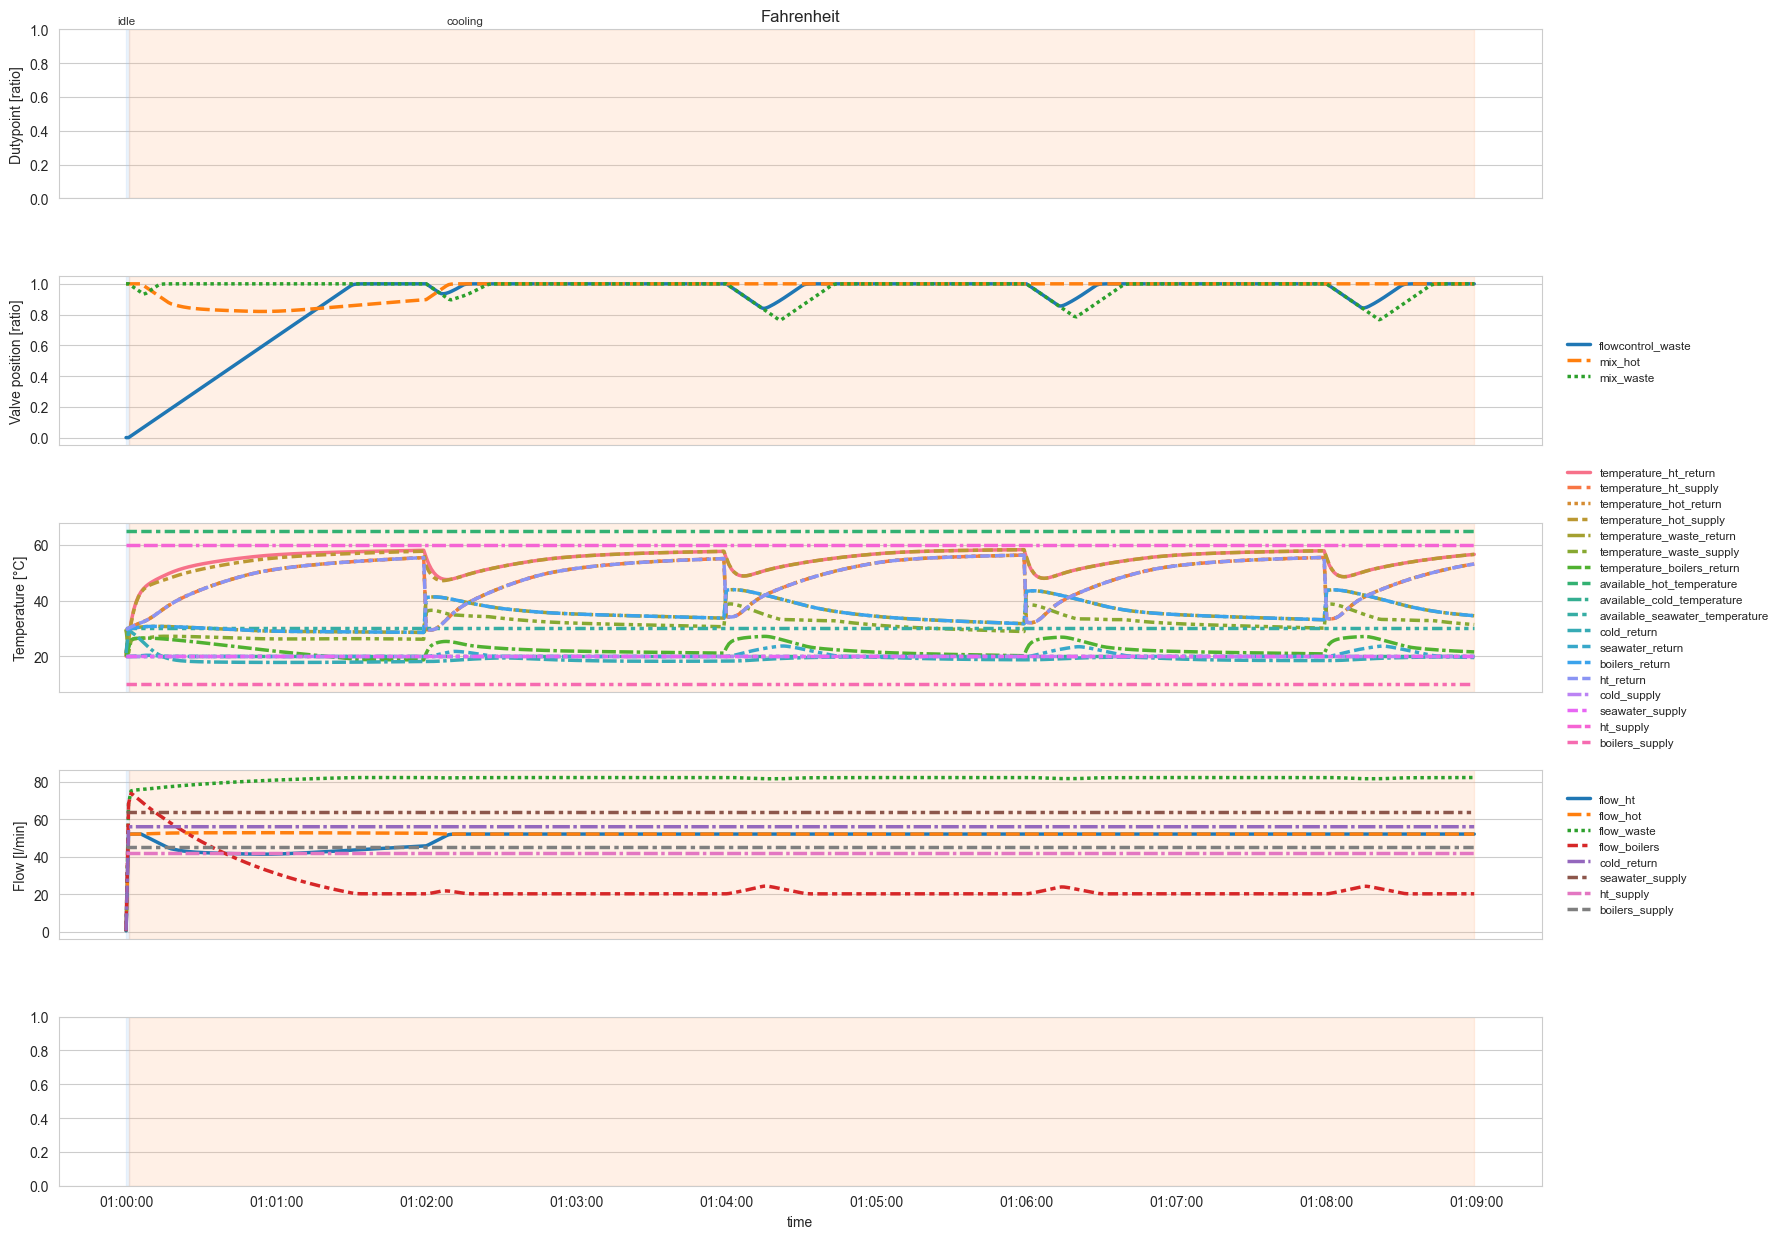

In [52]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/fahrenheit.png");

<Axes: >

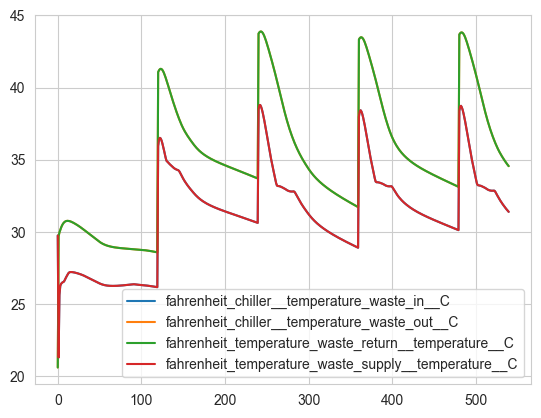

In [53]:
result[[col for col in result.columns if "temperature_waste" in col]].to_pandas().plot()

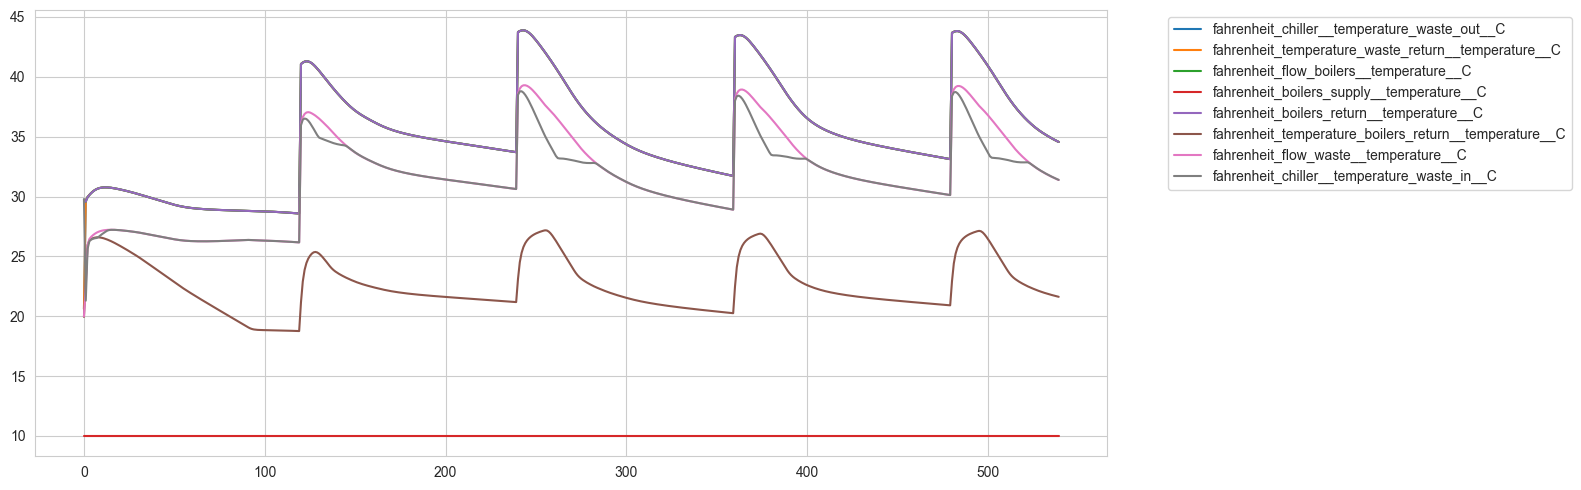

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

result[
    [
        "fahrenheit_chiller__temperature_waste_out__C",
        "fahrenheit_temperature_waste_return__temperature__C",
        "fahrenheit_flow_boilers__temperature__C",
        "fahrenheit_boilers_supply__temperature__C",
        "fahrenheit_boilers_return__temperature__C",
        "fahrenheit_temperature_boilers_return__temperature__C",
        "fahrenheit_flow_waste__temperature__C",
        "fahrenheit_chiller__temperature_waste_in__C",
    ]
].to_pandas().plot(ax=ax)

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

In [55]:
from thrs.simulation.io_mapping import flatten_model_values


result.select(
    [
        "time",
        *flatten_model_values(FahrenheitControlValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(FahrenheitSimulationInputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/pvt_run_inputs.csv")


result.select(
    [
        "time",
        *flatten_model_values(FahrenheitSensorValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(
            FahrenheitSimulationOutputs.zero(), fmu_only=False
        ).keys(),
    ]
).write_csv("csv/fahrenheit_run_outputs.csv")